# Exercise on resampling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pooch import retrieve
from sklearn.model_selection import train_test_split # splits data into train and test sets
from sklearn.preprocessing import PolynomialFeatures # creates a polynomial version of a variable (JULT)
from sklearn.linear_model import LinearRegression # fits the regression coefficients
from sklearn.metrics import mean_squared_error # calculates mean squared error
from sklearn.model_selection import KFold

## Validation set approach
1. Load data

In [2]:
# Read data, put in pandas dataframe
url = "https://raw.githubusercontent.com/luchem/bern02/refs/heads/main/Labs/pollution_cleaneddata.csv"
path = retrieve(url=url, known_hash=None)
df = pd.read_csv(path)
df

,PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO@,HUMID,MORT
0,36.0,27.0,71.0,8.1,3.34,11.4,81.5,3243.0,8.8,42.6,11.7,21.0,15.0,59.0,59.0,921.870
1,35.0,23.0,72.0,11.1,3.14,11.0,78.8,4281.0,3.5,50.7,14.4,8.0,10.0,39.0,57.0,997.875
2,44.0,29.0,74.0,10.4,3.21,9.8,81.6,4260.0,0.8,39.4,12.4,6.0,6.0,33.0,54.0,962.354
3,47.0,45.0,79.0,6.5,3.41,11.1,77.5,3125.0,27.1,50.2,20.6,18.0,8.0,24.0,56.0,982.291
4,43.0,35.0,77.0,7.6,3.44,9.6,84.6,6441.0,24.4,43.7,14.3,43.0,38.0,206.0,55.0,1071.289
5,53.0,45.0,80.0,7.7,3.45,10.2,66.8,3325.0,38.5,43.1,25.5,30.0,32.0,72.0,54.0,1030.380
6,43.0,30.0,74.0,10.9,3.23,12.1,83.9,4679.0,3.5,49.2,11.3,21.0,32.0,62.0,56.0,934.700
7,45.0,30.0,73.0,9.3,3.29,10.6,86.0,2140.0,5.3,40.4,10.5,6.0,4.0,4.0,56.0,899.529
8,36.0,24.0,70.0,9.0,3.31,10.5,83.2,6582.0,8.1,42.5,12.6,18.0,12.0,37.0,61.0,1001.902
9,36.0,27.0,72.0,9.5,3.36,10.7,79.3,4213.0,6.7,41.0,13.2,12.0,7.0,20.0,59.0,912.347


2. Specify a polynomial regression model with degree $p$ that predicts mortality as a function of the average July temperature in degrees F.

$$
y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \cdots + \beta_p x_i^p + \epsilon_i,
$$

or, more conceptually
$$
\text{mortality} = \beta_0 + \beta_1 \text{JULT} + \beta_2 \text{JULT}^2 + \cdots + \beta_p \text{JULT}^p + \epsilon
$$

3. Set a seed for the random number generator.

4. Split data into two equal sized sets, one for training and one for testing.

5. For polynomial models with degree 1 up to 4, derive the mean square error of prediction for the training and testing data sets, respectively. Note: It is ok to use built in functions for polynomial regression.

Present the results in a plot with polynomial degree on the x-axis and Mean Square Error on the y-axis (example provided below).

In [3]:
df = df[["JULT", "MORT"]] # Save only data that is interesting (JULT and MORT columns)
degrees = [1, 2, 3, 4, 5]

def split_data(random_seed = 0, test_size = 50):
    return train_test_split(df, test_size=test_size, random_state=random_seed) # Split data into two equal sized sets 

def polynomial_regression(train, test, degrees):
    # places to store the MSE
    mse_train = [] 
    mse_test = []

    for p in degrees: # p is the degree of the polynomial regression model
        poly = PolynomialFeatures(degree=p) # create the polynomial feature for the current degree p

        x_train = poly.fit_transform(train[["JULT"]]) # transforms JULT values to 1, JULT, JULT^2 for example
        x_test = poly.transform(test[["JULT"]]) # do the same for the test data

        model = LinearRegression() # create the regression model
        model.fit(x_train, train["MORT"]) # fit the model, using the transformed JULT values as predictions

        train_pred = model.predict(x_train) # make predictions for the training data
        test_pred = model.predict(x_test) # make predictions for the test data

        mse_train.append(mean_squared_error(train["MORT"], train_pred)) # calculate MSE
        mse_test.append(mean_squared_error(test["MORT"], test_pred))
    return mse_train, mse_test

mse_train, mse_test = polynomial_regression(*split_data(), degrees)


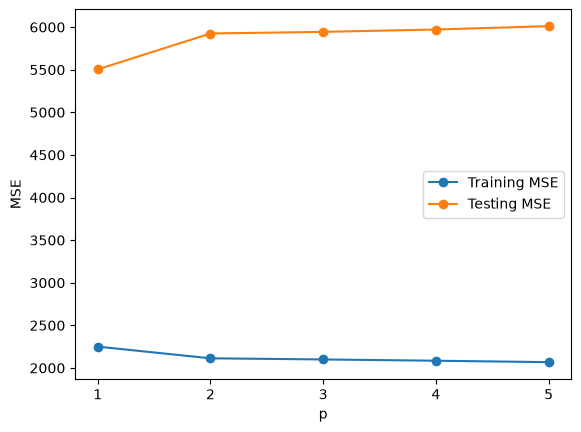

In [4]:
plt.plot(degrees, mse_train, marker="o", label="Training MSE")
plt.plot(degrees, mse_test, marker="o", label="Testing MSE")

plt.xlabel("p")
plt.ylabel("MSE")
plt.xticks(degrees)
plt.legend()
plt.show()

6. Judging from the graph you just generated, which degree of the polynomial would you recommend if the goal is to have a small variance of new predictions.

**Answer**: I woul choose a polynomial with degree 2 or 3, since the MSE decreases very slowly after p=2 and a lower degree is prefered to have a more simple model.

7. Repeat the procedure ten times but with other random seeds. Do you get similar results for other seeds?

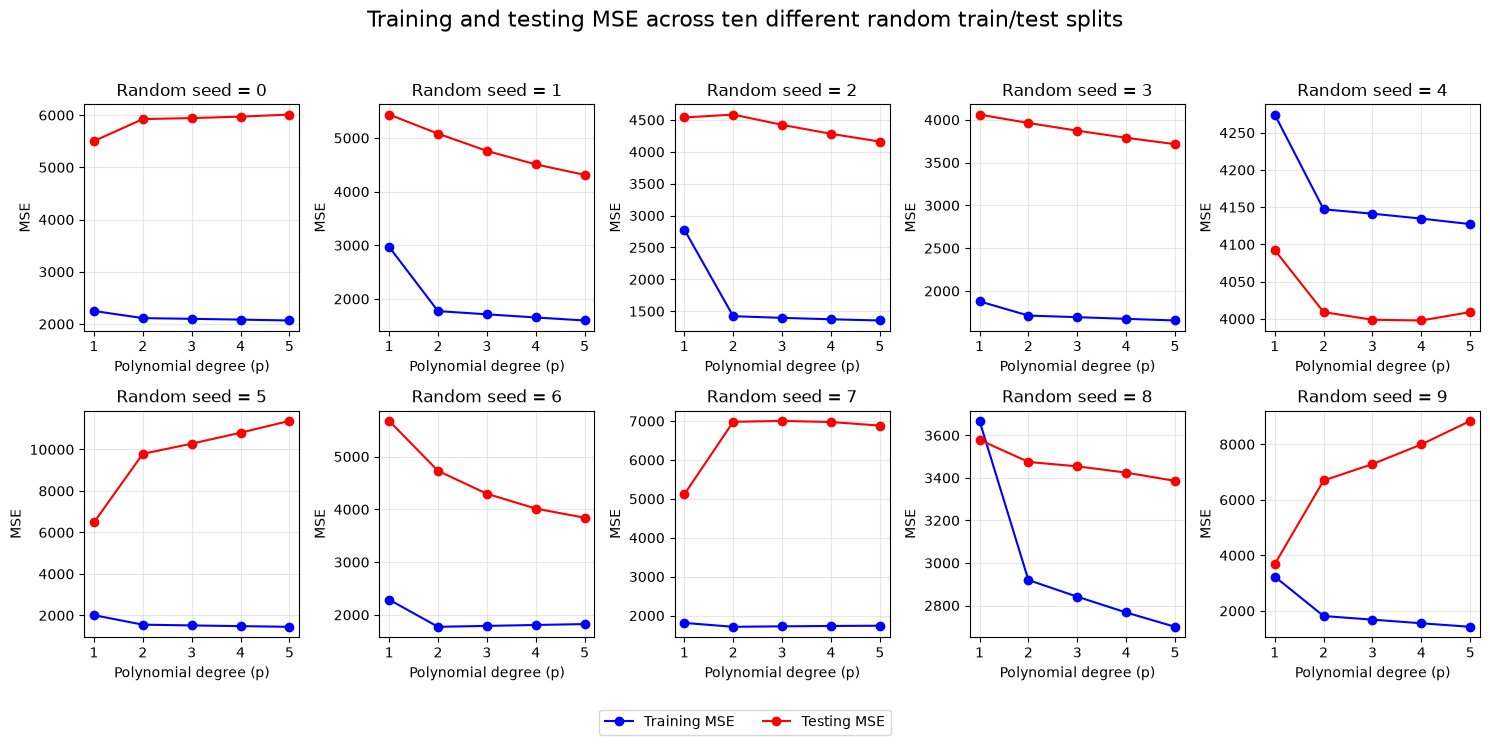

In [5]:
random_seeds = range(10)
degrees = [1, 2, 3, 4, 5]

mse_train_list = []
mse_test_list = []

fig, axes = plt.subplots(2, 5, figsize=(15, 7)) # Create one big figure with 10 subplots

for random_seed, ax in zip(random_seeds, axes.flat):
    mse_train, mse_test = polynomial_regression(*split_data(random_seed), degrees)
    mse_train_list.append(mse_train)
    mse_test_list.append(mse_test)

    # Plot training MSE
    ax.plot(
        degrees,
        mse_train,
        marker="o",
        color="blue",
        label="Training MSE")

    # Plot testing MSE
    ax.plot(
        degrees,
        mse_test,
        marker="o",
        color="red",
        label="Testing MSE")

    # Titles and axes
    ax.set_title(f"Random seed = {random_seed}")
    ax.set_xlabel("Polynomial degree (p)")
    ax.set_ylabel("MSE")
    ax.set_xticks(degrees)
    ax.grid(alpha=0.3)

fig.suptitle("Training and testing MSE across ten different random train/test splits", fontsize=16)

# One shared legend for the whole figure
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles,labels,loc="upper center",ncol=2,bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Looking at this plot, I would probably choose a higher degree of the polynomial (I choose to look at degree 5 here as well). 

## K-fold crossvalidation

8. Select a polynomial degree, e.g. $p=2$. Estimate the variance of predictions using the K-fold cross-validation approach where you hold out $K=3$ sets.

In [23]:
def k_fold_cv(kf):
    mse_test_list = []; mse_train_list = []

    for train_index, test_index in kf.split(df): # for each split in kf, give me the training and test set indexes
        # Get the test and train datasets using the kfold indices
        train = df.iloc[train_index]
        test = df.iloc[test_index]

        mse_train, mse_test = polynomial_regression(train, test, degrees = [2])
        
        mse_train_list.append(mse_train) # not needed?
        mse_test_list.append(mse_test)

    return mse_test_list


def print_results(mse_test_list):
    v_hat = np.sum(mse_test_list)/k # Estimate variance from the average test MSE

    for i, mse in enumerate(mse_test_list, start=1):
        print(f"Fold {i}: MSE = {mse[0]:.0f}")
    print(f"The estimated variance of predictions using the K-fold CV approach (k=3) is {v_hat:.0f}")


In [24]:
k = 3

# Create 3 train/test splits of the data
kf = KFold(n_splits=k, shuffle=True, random_state=0)

mse_test_list = k_fold_cv(kf)
print_results(mse_test_list)

Fold 1: MSE = 2529
Fold 2: MSE = 4591
Fold 3: MSE = 5028
The estimated variance of predictions using the K-fold CV approach (k=3) is 4049


9. Repeat the procedure ten times but with other random seeds. Do you get similar results for other seeds? If so, why?

In [27]:
k = 3

for random_seed in range(10):
    kf = KFold(n_splits=k, shuffle=True, random_state=random_seed)
    print_results(k_fold_cv(kf))

Fold 1: MSE = 2529
Fold 2: MSE = 4591
Fold 3: MSE = 5028
The estimated variance of predictions using the K-fold CV approach (k=3) is 4049
Fold 1: MSE = 5701
Fold 2: MSE = 7098
Fold 3: MSE = 2729
The estimated variance of predictions using the K-fold CV approach (k=3) is 5176
Fold 1: MSE = 7991
Fold 2: MSE = 2100
Fold 3: MSE = 5438
The estimated variance of predictions using the K-fold CV approach (k=3) is 5176
Fold 1: MSE = 2885
Fold 2: MSE = 5649
Fold 3: MSE = 2006
The estimated variance of predictions using the K-fold CV approach (k=3) is 3513
Fold 1: MSE = 2504
Fold 2: MSE = 4461
Fold 3: MSE = 4515
The estimated variance of predictions using the K-fold CV approach (k=3) is 3827
Fold 1: MSE = 2112
Fold 2: MSE = 2827
Fold 3: MSE = 6834
The estimated variance of predictions using the K-fold CV approach (k=3) is 3924
Fold 1: MSE = 7265
Fold 2: MSE = 4049
Fold 3: MSE = 5907
The estimated variance of predictions using the K-fold CV approach (k=3) is 5741
Fold 1: MSE = 4038
Fold 2: MSE = 4

**Answer**: Yes, I get similar results for the estimated variance of the predictions. I am getting very varied results for the individual mean squared errors which is expected. 

## The Bootstrap

Use the bootstrap to estimate the standard error of the slope of the line in the Poisson regression of the birds over time

10. Load the data set ‘bird_count.csv’

In [30]:
# Read data, put in pandas dataframe
df = pd.read_csv("/Users/andrearaaschou/courses/BERN02/exercises/glm/data/bird_count.csv")
df = df.sort_values("yr").reset_index(drop=True)        # sort data by year (in chronological order) + reset index
df["yr_mean_centered"] = df["yr"] - df["yr"].mean()     # create mean-centered year column

11. Retrieve the Poisson model fitted with maximum likelihood that you did earlier in the course.

Let $Y|x$ be the counted number of birds at year $x$.

$$
Y|x_i \sim Po(\lambda(x_i))
$$

The logarithm of the intensity is a linear model with an intercept $\beta_0$ and a slope $\beta_1$ parameter for year as the predictor $x$

$$
\log(\lambda_i) = \beta_0 + \beta_1x_i
$$

Using maximum likelihood based on all data, my estimate of the parameters is
$\hat{\beta}_1 = \text{[-0.03244]}$.

In [38]:
def bird_counts_model(df):
    x = df["yr_mean_centered"]
    y = df["count"]
    
    # Estimate intercept and slope using scipy minimize and likelihood function for poisson GLM
    return minimize(lambda beta: -log_likelihood(beta, x, y), x0=[0, 0]).x

def log_likelihood(beta, x, y):
    b0, b1 = beta
    return np.sum(-np.e**(b0 + b1*x) + y*(b0 + b1*x))

b0, b1 = bird_counts_model(df)

print(f"Estimated intercept: {b0:.4f}")
print(f"Estimated slope: {b1:.4f}")

Estimated intercept: 2.1082
Estimated slope: -0.0324


12. Use the bootstrap to approximate the standard error of the estimate of the slope parameter.

In [43]:
df.sample(n=len(df), replace=True) # This samples as many point as there are in the dataset with replacement

num_of_bootstraps = 500
bootstrap_b1 = []

# Estimate the slope using bootstrap sampling
for b in range(num_of_bootstraps):
    bootstrap_sample = df.sample(n=len(df), replace=True)
    _, b1 = bird_counts_model(bootstrap_sample)
    bootstrap_b1.append(b1)

In [46]:
# Estimate the standard error of the estimate of the slope parameter
se = np.std(bootstrap_b1, ddof=1)
print(f"Bootstrap standard error: {se:.4f}")

Bootstrap standard error: 0.0335


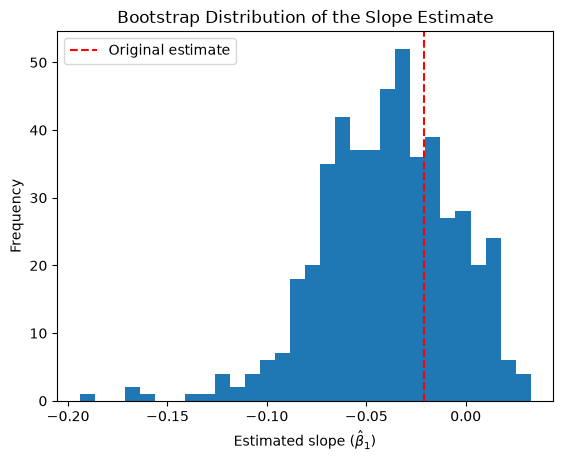

In [50]:
# Make histogram of bootstrap samples
plt.hist(bootstrap_b1, bins=30)
plt.axvline(b1, linestyle="--", label="Original estimate", color = "red")
plt.xlabel("Estimated slope ($\\hat{\\beta}_1$)")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of the Slope Estimate")
plt.legend()
plt.show()